# 🏋️ 第3步：训练 CNN 模型

## 本 Notebook 的学习目标

| 序号 | 知识点 | 要搞懂什么 |
|------|--------|-----------|
| ① | **损失函数 CrossEntropyLoss** | 怎么衡量"预测得有多错"？ |
| ② | **优化器 Adam** | 怎么根据 Loss 更新权重？ |
| ③ | **训练循环** | forward → loss → backward → update 每一步在做什么？ |
| ④ | **学习率调度** | 为什么训练到后面要减小学习率？ |
| ⑤ | **验证集评估** | 怎么判断模型是在学习还是过拟合？ |
| ⑥ | **Loss/Acc 曲线** | 怎么看懂训练过程？ |

> 💡 这是深度学习最重要的一个 Notebook——所有模型训练都遵循这个循环。

---
## Cell 1：导入库 & 加载数据（复用第1步的代码）

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import time

# ===== 设备 =====
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Apple MPS")
else:
    device = torch.device("cpu")
    print("🐢 CPU")

# ===== 数据预处理 =====
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),   # 随机水平翻转（数据增强）
    transforms.RandomCrop(32, padding=4),     # 随机裁剪（数据增强）
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# ===== 加载数据集 =====
full_dataset = ImageFolder(root='./CIFAR-100数据集/CIFAR-100数据集', transform=transform_train)
class_names = full_dataset.classes

targets = full_dataset.targets
train_idx, test_idx = [], []
for c in range(100):
    ci = [i for i, t in enumerate(targets) if t == c]
    train_idx.extend(ci[:500])
    test_idx.extend(ci[500:])

# 训练集用增强 transform，测试集用基础 transform
train_dataset = Subset(full_dataset, train_idx)
# 测试集需要单独创建，用不同的 transform
full_test = ImageFolder(root='./CIFAR-100数据集/CIFAR-100数据集', transform=transform_test)
test_dataset = Subset(full_test, test_idx)

batch_size = 64 #批次大小，可调整为128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2) #数据loader
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2) #测试集不需要打乱

print(f"训练集: {len(train_dataset)} 张, 测试集: {len(test_dataset)} 张")
print(f"类别数: {len(class_names)}")
print(f"每个 epoch: {len(train_loader)} 个 batch")

🚀 Apple MPS
训练集: 50000 张, 测试集: 10000 张
类别数: 100
每个 epoch: 782 个 batch


---
## Cell 2：定义模型（复用第2步的代码）

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout(dropout)
        )
    def forward(self, x): return self.block(x)

class CIFAR100_CNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64, dropout=0.2), ConvBlock(64, 128, dropout=0.3),
            ConvBlock(128, 256, dropout=0.4), ConvBlock(256, 512, dropout=0.4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(512*2*2, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

model = CIFAR100_CNN(num_classes=100).to(device)
print(f"模型参数: {sum(p.numel() for p in model.parameters()):,}")
print(f"设备: {next(model.parameters()).device}")

模型参数: 5,239,460
设备: mps:0


---
## Cell 3：理解损失函数 CrossEntropyLoss

### 🤔 Loss 是什么？

Loss = **模型预测和正确答案之间的差距**。数值越大 = 错得越离谱。

### CrossEntropyLoss（交叉熵损失）

分类任务的标准选择。它做两件事：
1. **Softmax**：把 100 个原始得分变成概率（加起来=1）
2. **负对数似然**：正确类别的概率越高，Loss 越低

```
模型输出: [2.1, 0.3, -1.5, ...]  ← 100个"得分"，越高越像
                  ↓ Softmax
概率分布: [0.65, 0.11, 0.02, ...]  ← 加起来 = 1
                  ↓ -log(p_correct)
Loss:     0.43                      ← 正确答案概率 0.65 → Loss = -log(0.65)
```

### 一句话：**Loss 就是模型"有多错"，训练目标就是让 Loss 越小越好。**

In [8]:
# 损失函数：分类任务标配
criterion = nn.CrossEntropyLoss()

# 演示：假设模型输出 4 张图的 100 类得分
demo_out = torch.randn(4, 100)          # [batch=4, 100类]
demo_label = torch.tensor([5, 23, 67, 89])  # 正确答案

loss = criterion(demo_out, demo_label)
print(f"随机预测的 Loss: {loss.item():.4f}")

# 如果预测完全正确呢？
perfect_out = torch.zeros(4, 100)
for i, l in enumerate(demo_label):
    perfect_out[i, l] = 100.0   # 给正确答案超高分
loss_perfect = criterion(perfect_out, demo_label)
print(f"完美预测的 Loss: {loss_perfect.item():.6f}  ← 接近 0")

# 如果瞎猜呢？
random_out = torch.randn(4, 100) * 0.01  # 所有得分差不多
loss_random = criterion(random_out, demo_label)
print(f"瞎猜的 Loss:     {loss_random.item():.4f}  ← 约 -log(1/100) = 4.6")

随机预测的 Loss: 5.2498
完美预测的 Loss: 0.000000  ← 接近 0
瞎猜的 Loss:     4.5986  ← 约 -log(1/100) = 4.6


---
## Cell 4：理解优化器 Adam

### 🤔 优化器做什么？

Loss 告诉模型"你错了多少"，优化器负责**根据 Loss 调整每个参数**，让下次预测更准。

### 关键概念：学习率 (Learning Rate)

```
新权重 = 旧权重 - 学习率 × 梯度

梯度 = Loss 对每个参数的偏导数（指向 Loss 增加最快的方向）
所以 "减去 学习率×梯度" = 向 Loss 减小的方向走一步
```

```
学习率太大 → 跳来跳去不收敛
学习率太小 → 收敛太慢
学习率适中 → 稳定下降 ✅

示意图:
  Loss ↑
       │  ╲ (太大)     ╱╲ (适中)
       │   ╲          ╱  ╲___
       │    ╲___     ╱        ╲___
       │        ╲__╱               ╲___  (太小，龟速)
       └──────────────────────────────→ 训练步数
```

### Adam vs SGD

| | SGD | Adam |
|------|-----|------|
| 速度 | 慢 | 快 |
| 调参 | 需要精心调学习率 | 默认参数就很好 |
| 适用 | 追求极致效果 | 日常使用首选 |

**初学用 Adam，省心效果好。**

In [9]:
# AdamW = Adam + Weight Decay（权重衰减，也是一种正则化）
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
#                        ↑                ↑       ↑
#                        模型所有参数      学习率   L2 正则化系数

# 学习率调度器：当验证 Loss 不再下降时，学习率自动减半
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min',      # 监控指标越小越好（Loss）
    factor=0.5,                 # 降到原来的 0.5 倍
    patience=5,                 # 连续 5 个 epoch 没改善就降
)

print(f"初始学习率: {optimizer.param_groups[0]['lr']}")
print(f"优化器: AdamW")

初始学习率: 0.001
优化器: AdamW


---
## Cell 5：理解训练循环 —— 深度学习最核心的代码

### 一个 batch 的训练流程

```
① 取一批数据 (图片 + 标签)
       ↓
② 清空梯度       optimizer.zero_grad()
       ↓
③ 前向传播       outputs = model(images)    ← 预测
       ↓
④ 计算 Loss      loss = criterion(outputs, labels)  ← 差距
       ↓
⑤ 反向传播       loss.backward()            ← 算梯度
       ↓
⑥ 更新参数       optimizer.step()           ← 走一步
       ↓
⑦ 重复 ①~⑥，直到看完所有数据 = 一个 Epoch
```

### 为什么用 `model.train()` 和 `model.eval()`？

| 模式 | Dropout | BatchNorm | 什么时候用 |
|------|---------|-----------|-----------|
| `model.train()` | ✅ 随机丢弃 | ✅ 用当前 batch 统计 | 训练时 |
| `model.eval()` | ❌ 全保留 | ❌ 用全局统计 | 验证/测试时 |

### 为什么用 `torch.no_grad()`？

验证时不需要算梯度（不更新参数），`no_grad()` 关闭自动求导可以省显存、加速。

---
## Cell 6：训练函数和验证函数

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device): #对应了模型结构、数据loader方法、损失函数、参数优化、设备
    """训练一个 epoch，返回平均 Loss 和 Accuracy"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # ① 清空梯度
        optimizer.zero_grad() #为什么要清空梯度？

        # ② 前向传播
        outputs = model(images)

        # ③ 计算 Loss
        loss = criterion(outputs, labels) #这里的labels是否会转为one hot？

        # ④ 反向传播（算梯度）
        loss.backward()

        # ⑤ 更新参数
        optimizer.step()

        # ⑥ 统计
        running_loss += loss.item() #一批loss的和
        _, predicted = outputs.max(1)   # 得分最高的类 = 预测结果
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item() #记录这一个batch的正确个数

    avg_loss = running_loss / len(loader) #这是一个epoch的平均loss
    accuracy = 100. * correct / total
    return avg_loss, accuracy


@torch.no_grad()  # ← 不计算梯度，省显存
def validate(model, loader, criterion, device):
    """在验证集上评估模型，返回 Loss 和 Accuracy"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

print("✅ 训练/验证函数已定义")

✅ 训练/验证函数已定义


---
## Cell 7：开始训练！🔥

这也是耗时最长的 cell。在你的 M5 上，每个 epoch 大约 30~60 秒。

训练 40 个 epoch，预计 20~40 分钟。观察 Loss 下降和 Accuracy 上升的过程。

In [11]:
# ===== 训练配置 =====
num_epochs = 40
best_acc = 0.0

# 记录历史（画曲线用）
history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': [],
    'lr': []
}

print(f"开始训练 {num_epochs} 个 epoch...")
print(f"设备: {device}")
print("=" * 60)

start_time = time.time()

for epoch in range(num_epochs):
    # 训练一个 epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # 验证
    test_loss, test_acc = validate(model, test_loader, criterion, device)

    # 学习率调度（根据验证 Loss 决定是否降学习率）
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(test_loss)

    # 记录历史
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)

    # 保存最佳模型
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')

    # 打印进度
    lr_changed = "⬇️" if epoch > 0 and current_lr != history['lr'][-2] else " "
    print(f"Epoch {epoch+1:3d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}% {lr_changed}")

elapsed = time.time() - start_time
print("=" * 60)
print(f"训练完成！耗时: {elapsed//60:.0f}分{elapsed%60:.0f}秒")
print(f"最佳测试准确率: {best_acc:.2f}%")

开始训练 40 个 epoch...
设备: mps
Epoch   1/40 | Train Loss: 4.4463 | Train Acc: 2.02% | Test Loss: 4.2028 | Test Acc: 4.06%  
Epoch   2/40 | Train Loss: 4.3158 | Train Acc: 2.86% | Test Loss: 4.1258 | Test Acc: 4.62%  
Epoch   3/40 | Train Loss: 4.2664 | Train Acc: 3.21% | Test Loss: 4.0424 | Test Acc: 5.19%  
Epoch   4/40 | Train Loss: 4.2406 | Train Acc: 3.26% | Test Loss: 4.0050 | Test Acc: 5.37%  
Epoch   5/40 | Train Loss: 4.2045 | Train Acc: 3.48% | Test Loss: 3.9220 | Test Acc: 7.39%  
Epoch   6/40 | Train Loss: 4.0886 | Train Acc: 4.76% | Test Loss: 3.8353 | Test Acc: 7.18%  
Epoch   7/40 | Train Loss: 3.9867 | Train Acc: 5.71% | Test Loss: 3.7424 | Test Acc: 8.74%  
Epoch   8/40 | Train Loss: 3.8495 | Train Acc: 7.19% | Test Loss: 3.4805 | Test Acc: 12.63%  
Epoch   9/40 | Train Loss: 3.7321 | Train Acc: 9.24% | Test Loss: 3.3794 | Test Acc: 14.42%  
Epoch  10/40 | Train Loss: 3.6011 | Train Acc: 11.08% | Test Loss: 3.1944 | Test Acc: 19.19%  
Epoch  11/40 | Train Loss: 3.4639 | Tra

---
## Cell 8：画出训练曲线

训练曲线是判断模型状态的最重要工具：

- **Loss 曲线**：训练和验证 Loss 都下降 → 在正常学习
- **过拟合**：训练 Loss 继续降，验证 Loss 上升 → 需要更多正则化
- **欠拟合**：两个 Loss 都高且不降 → 模型太小或学习率不对

/var/folders/xk/30ms3pwn3qn2c3nl828zvw340000gn/T/ipykernel_3921/3213903970.py:29: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xk/30ms3pwn3qn2c3nl828zvw340000gn/T/ipykernel_3921/3213903970.py:29: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xk/30ms3pwn3qn2c3nl828zvw340000gn/T/ipykernel_3921/3213903970.py:29: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xk/30ms3pwn3qn2c3nl828zvw340000gn/T/ipykernel_3921/3213903970.py:29: UserWarning: Glyph 20064 (\N{CJK UNIFIED IDEOGRAPH-4E60}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xk/30ms3pwn3qn2c3nl828zvw340000gn/T/ipykernel_3921/3213903970.py:29: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/xk/30ms3pwn3

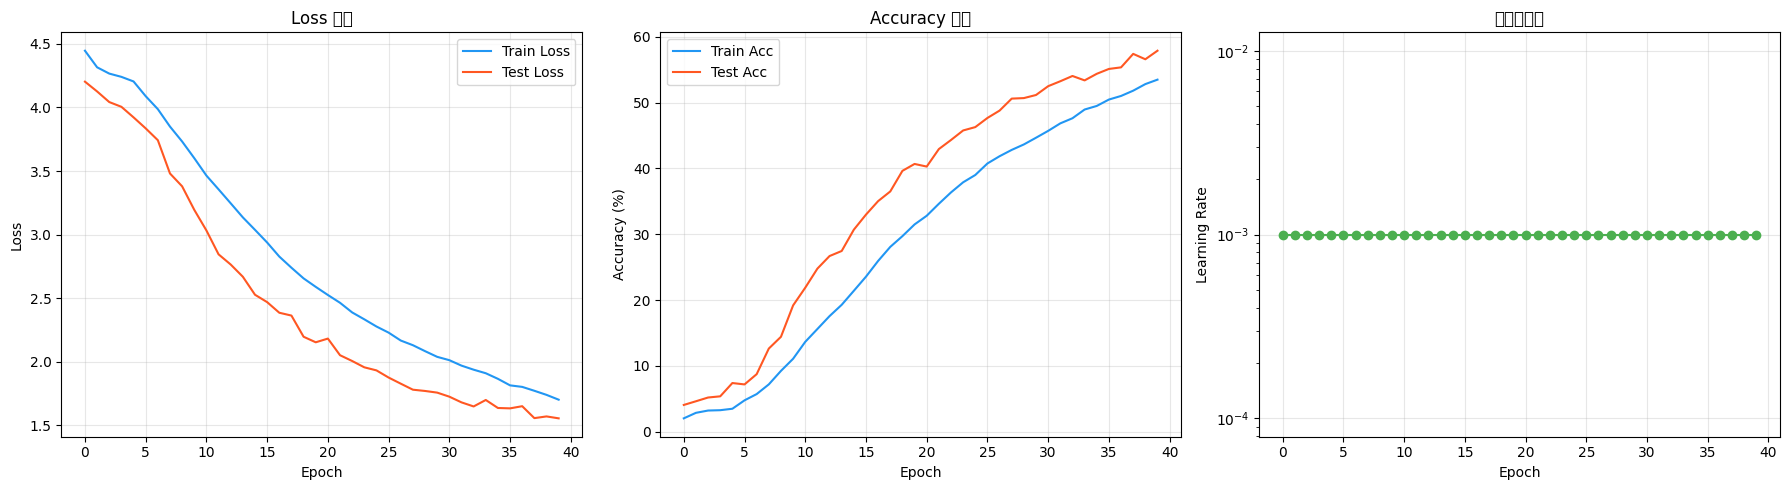

✅ 曲线已保存为 training_curves.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss 曲线
axes[0].plot(history['train_loss'], label='Train Loss', color='#2196F3')
axes[0].plot(history['test_loss'], label='Test Loss', color='#FF5722')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss 曲线')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy 曲线
axes[1].plot(history['train_acc'], label='Train Acc', color='#2196F3')
axes[1].plot(history['test_acc'], label='Test Acc', color='#FF5722')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy 曲线')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 学习率变化
axes[2].plot(history['lr'], color='#4CAF50', marker='o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('学习率变化')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')  # 对数刻度，更好看变化

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ 曲线已保存为 training_curves.png")

---
## Cell 9：加载模型 & 在测试集上最终评估

In [13]:
# 加载训练中保存的最佳模型
model.load_state_dict(torch.load('best_model.pth', weights_only=True))
model = model.to(device)

# 最终评估
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"最终测试结果:")
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.2f}%")
print(f"  (随机猜的准确率是 1/100 = 1%，所以 >1% 就说明在学)")

最终测试结果:
  Loss:     1.5543
  Accuracy: 57.90%
  (随机猜的准确率是 1/100 = 1%，所以 >1% 就说明在学)


---
## 🎉 第3步完成！你理解了深度学习的核心循环

```
训练循环 = 所有深度学习项目的"骨架"

   ① 取数据        →  DataLoader
   ② 清空梯度      →  optimizer.zero_grad()
   ③ 前向传播      →  model(images)
   ④ 计算 Loss     →  criterion(outputs, labels)
   ⑤ 反向传播      →  loss.backward()
   ⑥ 更新参数      →  optimizer.step()
   ⑦ 重复          →  下一个 batch
```

| ✅ | 知识点 | 一句话 |
|----|--------|--------|
| ① | **CrossEntropyLoss** | 衡量预测和正确答案的差距 |
| ② | **AdamW** | 根据梯度自动调整每个参数的学习率 |
| ③ | **训练循环** | zero_grad → forward → loss → backward → step |
| ④ | **验证** | model.eval() + no_grad()，不更新参数只看效果 |
| ⑤ | **学习率调度** | 验证 Loss 不降时自动减小学习率 |
| ⑥ | **过拟合判断** | 训练 Acc 升、验证 Acc 降 → 过拟合 |
| ⑦ | **模型保存** | 保存验证集上最好的那个模型 |

> 📝 看看你的训练曲线：训练和验证 Loss 都稳定下降吗？最终准确率到多少了？